<a href="https://colab.research.google.com/github/GreenVaultJoe/capstone_project/blob/main/eda_master_kpi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!git clone https://github.com/GreenVaultJoe/capstone_project.git


Cloning into 'capstone_project'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 74 (delta 24), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 13.50 MiB | 3.24 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
os.getcwd()


'/content'

In [7]:
os.listdir("capstone_project/data/raw_data")

['master_kpi_part_5_of_6.csv',
 'master_kpi_part_4_of_6.csv',
 'master_kpi_part_2_of_6.csv',
 'master_kpi_part_3_of_6.csv',
 'Residential_Solar_Investment_Program_(RSIP)_Enrollment_20251119.csv',
 'master_kpi_part_6_of_6.csv',
 'README.txt',
 'master_kpi_part_1_of_6.csv']

In [9]:
from pathlib import Path
import pandas as pd

data_dir = Path("capstone_project/data/raw_data")

files = sorted(data_dir.glob("master_kpi_part_*_of_6.csv"))

print(files)  # sanity check

df = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)

df.head()


[PosixPath('capstone_project/data/raw_data/master_kpi_part_1_of_6.csv'), PosixPath('capstone_project/data/raw_data/master_kpi_part_2_of_6.csv'), PosixPath('capstone_project/data/raw_data/master_kpi_part_3_of_6.csv'), PosixPath('capstone_project/data/raw_data/master_kpi_part_4_of_6.csv'), PosixPath('capstone_project/data/raw_data/master_kpi_part_5_of_6.csv'), PosixPath('capstone_project/data/raw_data/master_kpi_part_6_of_6.csv')]


/tmp/ipython-input-615283305.py:11: DtypeWarning: Columns (8,28,29,34,39,43,47,50,107,108) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f) for f in files],
/tmp/ipython-input-615283305.py:11: DtypeWarning: Columns (24,41,54,60) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f) for f in files],
/tmp/ipython-input-615283305.py:11: DtypeWarning: Columns (13,29) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f) for f in files],
/tmp/ipython-input-615283305.py:11: DtypeWarning: Columns (13,28,33,34,40,43,44,47,48,49,50,81,160) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f) for f in files],


,Current Reporting Period,ProjectCounter,ProjectUnitCounter,Duplicate,Entity,Sector,Product,Class,Channel,Status,...,Contractor Id,CRA Qualified,LMI Qualified,COG Name,Cost Membership,DOE_Justice40,SQL_Source,PropertyTaxesGenerated,LastModifiedDate,file_part
0,NaN,1,1,No,CGB,Residential,NaN,NaN,NaN,Completed,...,TBD,Not CRA,LMI,Capitol,No,Not Justice 40,v_RESI_ALL_PROGRAMS_KPI,0.0,NaN,1
1,NaN,1,1,No,CCEF,Infrastructure,NaN,EPBB,NaN,Completed,...,TBD,Not CRA,Not LMI,Western CT,No,Not Justice 40,v_RSIP_ALL_PROGRAMS_KPI,0.0,NaN,1
2,NaN,1,1,No,CCEF,Infrastructure,NaN,EPBB,NaN,Completed,...,TBD,Not CRA,LMI,Northwest Hills,Yes,Not Justice 40,v_RSIP_ALL_PROGRAMS_KPI,0.0,NaN,1
3,NaN,1,1,No,CGB,Residential,NaN,NaN,NaN,Completed,...,TBD,Not CRA,Not LMI,Capitol,No,Not Justice 40,v_RESI_ALL_PROGRAMS_KPI,0.0,NaN,1
4,2025-09-30 00:00:00.000,1,1,No,CGB,Residential,NaN,NaN,NaN,Completed,...,TBD,CRA,Not LMI,Naugatuck Valley,Yes,Not Justice 40,v_RESI_ALL_PROGRAMS_KPI,0.0,NaN,1


In [17]:
#rename columns for easy reading and coding
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_")
)
list(df.columns)


['current_reporting_period',
 'projectcounter',
 'projectunitcounter',
 'duplicate',
 'entity',
 'sector',
 'product',
 'class',
 'channel',
 'status',
 'projectcode',
 'municipality',
 'state',
 'zip',
 'county',
 'censustract',
 'current_msa_ami_band',
 'vintage_msa_ami_band',
 'current_msa_smi_band',
 'vintage_msa_smi_band',
 'current_distressed',
 'vintage_distressed',
 'electricutility',
 'contractor',
 'lender',
 'market',
 'projecttype',
 'technology',
 'rsip_step',
 'bundle_type',
 'smartebundle',
 'smartenaturalgasspecialoffer',
 'smarteheatpumpspecialoffer',
 'solarleasetype',
 'propertytype',
 'food/organic_waste_(tons/yr)',
 'numberofmeasures',
 'multimeasure',
 'square_footage',
 'fundingsource',
 'sf_record_type',
 'orphanstatus',
 'powerclerknumber',
 'pacenumber',
 'mfhnumber',
 'irbrequestnumber',
 'solarize',
 'rsip_system_financing_type',
 'resi_financing',
 'shrec',
 'rec_type',
 'term',
 'rate',
 'ppa_lease_price',
 'rate_type',
 'esa_opt_in',
 'esa_price',
 'month

In [11]:
df.info()
df.isna().sum().head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67816 entries, 0 to 67815
Columns: 181 entries, current_reporting_period to file_part
dtypes: float64(85), int64(13), object(83)
memory usage: 93.6+ MB


,0
current_reporting_period,4689
projectcounter,0
projectunitcounter,0
duplicate,0
entity,0
sector,1461
product,21117
class,19648
channel,57655
status,0


In [12]:
df.describe()


,projectcounter,projectunitcounter,censustract,smartebundle,smartenaturalgasspecialoffer,smarteheatpumpspecialoffer,food/organic_waste_(tons/yr),numberofmeasures,multimeasure,square_footage,...,individualincometaxesgenerated,corporatetaxesgenerated,salestaxesgenerated,totaltaxrevenuegenerated,zrec_kwh,zrec_mwh,vintage_msa_ami_band_sort,msa_vintage_cra_ami_band_sort,propertytaxesgenerated,file_part
count,67816.000000,67816.000000,67707.000000,4086.000000,4086.000000,4086.000000,0.0,16347.000000,0.0,477.000000,...,6.751300e+04,6.751300e+04,6.751300e+04,6.781600e+04,47907.000000,47907.000000,67816.000000,67816.000000,67513.000000,67816.000000
mean,1.120031,1.363749,380739.096932,0.297846,0.124082,0.079785,NaN,1.310822,NaN,52495.991614,...,1.047436e+03,1.064067e+03,6.354635e+02,2.761137e+03,0.042055,42.054554,3.856184,3.073228,26.562399,3.499941
std,15.758745,17.317301,237607.274966,0.457368,0.329716,0.270993,NaN,0.716506,NaN,75363.343110,...,1.655137e+04,9.221639e+03,2.731877e+04,5.104349e+04,0.055300,55.299675,1.283016,0.854620,2759.533578,1.707826
min,1.000000,1.000000,10101.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,450.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.003700,3.700000,1.000000,1.000000,0.000000,1.000000
25%,1.000000,1.000000,165500.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,15824.000000,...,3.977500e+02,3.839600e+02,0.000000e+00,8.664225e+02,0.017400,17.400000,3.000000,3.000000,0.000000,2.000000
50%,1.000000,1.000000,400200.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,29504.000000,...,5.632700e+02,6.498200e+02,0.000000e+00,1.250730e+03,0.023700,23.700000,4.000000,3.000000,0.000000,3.000000
75%,1.000000,1.000000,524100.000000,1.000000,0.000000,0.000000,NaN,1.000000,NaN,56680.000000,...,7.782200e+02,9.506400e+02,0.000000e+00,1.781847e+03,0.035800,35.800000,5.000000,4.000000,0.000000,5.000000
max,4012.000000,4012.000000,908100.000000,1.000000,1.000000,1.000000,NaN,10.000000,NaN,850000.000000,...,2.775257e+06,1.169372e+06,3.789833e+06,6.054917e+06,0.387700,387.700000,6.000000,5.000000,632722.500000,6.000000


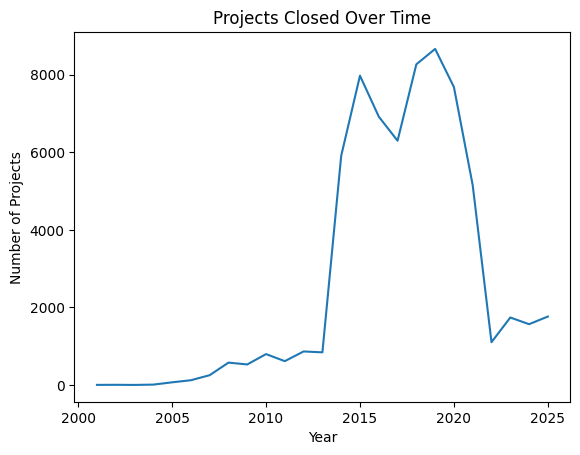

In [21]:
df['closeddate'] = pd.to_datetime(df['closeddate'], errors='coerce')

df.groupby(df['closeddate'].dt.year).size().plot()
plt.title("Projects Closed Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.show()
